# Pipeline Definitivo: Preprocesamiento Visual + EasyOCR + Validadores Múltiples\nEste notebook consolida las técnicas de limpieza morfológica (Background Subtraction, Umbralización) del Notebook 2, inyectándolas directamente en los Recortes (ROIs) antes de pasarlos por las redes neuronales puras de EasyOCR (Notebook 3).

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from datasets import load_dataset
import easyocr
import random
import re

print("Cargando librerías. Esto puede tardar unos segundos...")


C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando librerías. Esto puede tardar unos segundos...


## 1. Módulo de Limpieza Visual (Preprocesamiento Matemático)\nAislamos las operaciones morfológicas encargadas de eliminar sombras, arrugas y suciedad del fondo del ticket para maximizar el contraste de las letras.

In [2]:
def preprocess_image_for_ocr(img_bgr):
    """
    Aplica Background Subtraction y Umbralización de Otsu a un recorte BGR.
    Retorna la imagen preprocesada en un solo canal (blanco y negro puro).
    """
    # 1. Escala de grises
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # 2. Estimar el fondo (Background Subtraction)
    dilated_img = cv2.dilate(gray, np.ones((7,7), np.uint8))
    bg_img = cv2.medianBlur(dilated_img, 21)
    
    # 3. Restar fondo a la original
    # Usamos cast a int16 para evitar underflow (valores negativos)
    diff_img = 255 - cv2.absdiff(gray, bg_img)
    
    # 4. Normalizar la imagen al rango 0-255 correctamente 
    # (cv2.normalize devuelve float o int según el dytpe destino)
    norm_img = cv2.normalize(diff_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
    
    # 5. Binarización (Umbralización de Otsu) para forzar blanco puro o negro puro
    # Aplicamos Thresh Binary Inv si el texto quedó claro sobre fondo oscuro, o al revés.
    # Tras diff_img, el fondo es ~255 y el texto oscila. Otsu lo separará perfectamente.
    _, thresh = cv2.threshold(norm_img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    return thresh


## 2. Motor de Arquitectura Híbrida\nInstanciamos la clase que recorta las zonas, las limpia con nuestra función matemática, y las lee con la Inteligencia Artificial de EasyOCR.

In [3]:
class SimpleRegionDetector:
    """
    Simula una CNN tipo Faster R-CNN mediante promedios estadísticos de estructura geométrica.
    """
    def crop_regions(self, img):
        h, w = img.shape[:2]
        regions = {
            'Header': img[0:int(0.25*h), 0:w],
            'Body': img[int(0.25*h):int(0.80*h), 0:w],
            'Footer': img[int(0.80*h):h, 0:w]
        }
        return regions

class AdvancedOCREngine:
    def __init__(self):
        try:
            self.reader = easyocr.Reader(['es', 'en'], gpu=True) 
            print("[INFO] EasyOCR corriendo en GPU (Aceleración activada).")
        except:
            self.reader = easyocr.Reader(['es', 'en'], gpu=False)
            print("[INFO] EasyOCR corriendo en CPU.")
            
    def process_and_extract(self, original_img):
        detector = SimpleRegionDetector()
        crops = detector.crop_regions(original_img)
        
        extracted_data = {}
        raw_lists = {} # Mantener la lista separada para evaluar saltos de línea
        preprocessed_crops = {} 
        
        for region_name, crop in crops.items():
            clean_crop = preprocess_image_for_ocr(crop)
            preprocessed_crops[region_name] = clean_crop
            
            # detail=0 devuelve lista de strings geométricamente ordenados (de arriba a abajo, izq a der)
            results = self.reader.readtext(clean_crop, detail=0)
            raw_lists[region_name] = results
            
            text = " ".join(results)
            extracted_data[region_name] = text.strip()
            
        return extracted_data, raw_lists, preprocessed_crops
        
    def find_total_value(self, raw_text_list):
        """
        Busca las palabras 'Total' o 'TL' (case-insensitive) y extrae el primer valor
        numérico sólido que aparece a su derecha en la misma línea, o en el siguiente
        bloque geométrico detectado por la IA.
        """
        # Detectamos TOTAL o TL ignorando mayúsculas y signos de puntuación pegados
        keyword_regex = re.compile(r'\b(TOTAL|TL)\b', re.IGNORECASE)
        # Detectamos divisas opcionales y el número posterior
        number_regex = re.compile(r'([$€£]?\s*\d+[\.,\s]*\d*)')
        
        for i, text in enumerate(raw_text_list):
            if keyword_regex.search(text):
                match_kw = keyword_regex.search(text)
                
                # Caso 1: El OCR detectó el "TOTAL" y su "VALOR" pegados en la misma caja de texto
                right_part = text[match_kw.end():]
                num_match = number_regex.search(right_part)
                
                # Si a la derecha hay un número válido (ej. TOTAL 15.00)
                if num_match and any(char.isdigit() for char in num_match.group(1)):
                    return num_match.group(1).strip()
                    
                # Caso 2: El OCR fragmentó "TOTAL" y el "VALOR" en dos cajas vecinas
                # Como EasyOCR ordena la lista izquierda->derecha, el valor será el text[i+1]
                if i + 1 < len(raw_text_list):
                    next_text = raw_text_list[i+1]
                    next_num_match = number_regex.search(next_text)
                    if next_num_match and any(char.isdigit() for char in next_num_match.group(1)):
                        return next_num_match.group(1).strip()
                        
        return None

ocr_engine = AdvancedOCREngine()

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[INFO] EasyOCR corriendo en GPU (Aceleración activada).


## 3. Pruebas Cíclicas Multi-Imagen con Dataset CORD\nCargamos el entorno, extraemos diversas facturas, y para cada una dibujamos el *Antes* (crudo), el *Durante* (preprocesado) y el *Después* (predicho).

Descargando / Cargando partición de test del Dataset CORD...



  EVALUANDO FACTURA ÍNDICE: 37


C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


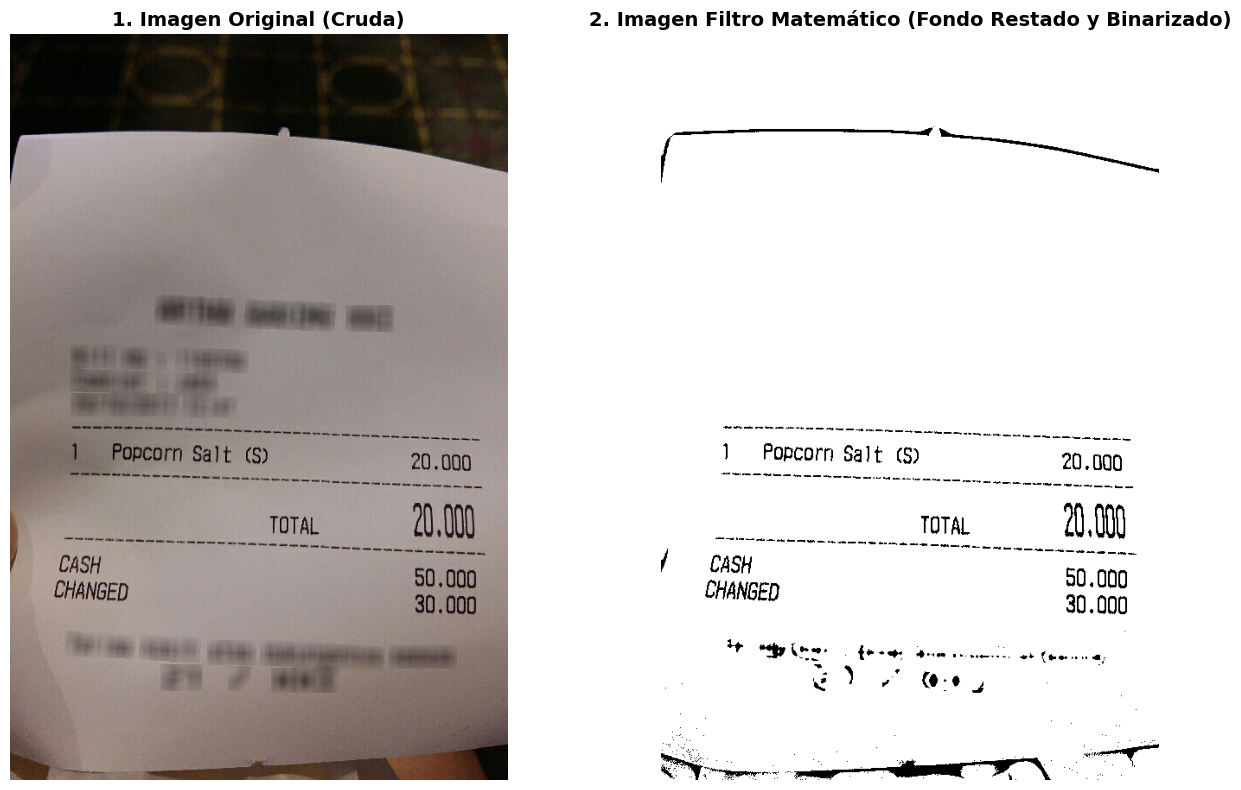

-------------- 3. RESULTADOS PREDICHOS (IA & BUSCADOR SEMÁNTICO) ---------------
  • HEADER: 
  • BODY: Popcorn Salt (S) 20.000 TotAL 20,€00 CASH 50.000 CHANGED 30.000
  • FOOTER: 4 "4(2-

  >> ✨ TOTAL DETECTADO TRAS PALABRA CLAVE ('Total' o 'TL'):  20,




  EVALUANDO FACTURA ÍNDICE: 47


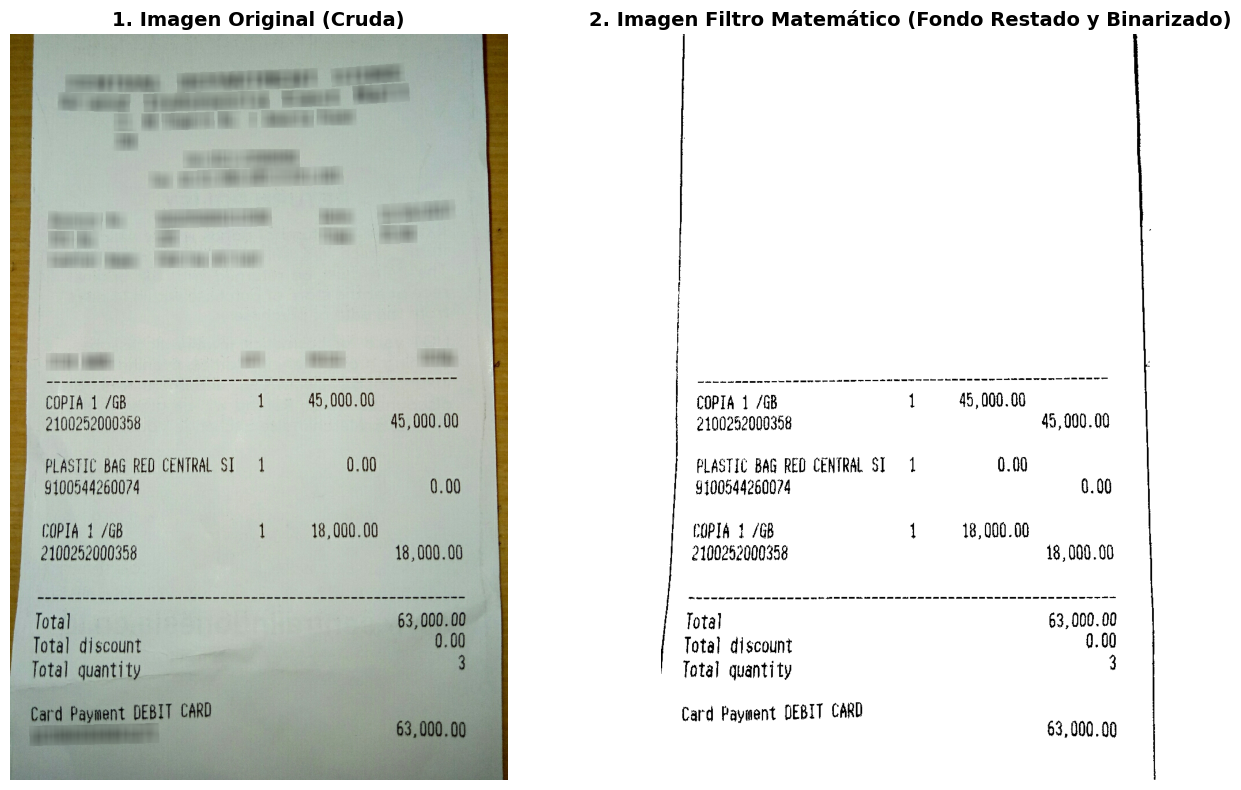

-------------- 3. RESULTADOS PREDICHOS (IA & BUSCADOR SEMÁNTICO) ---------------
  • HEADER: 
  • BODY: CopiA /GB 45 , 000.00 2100252000358 45 , 000.00 PLASTIC BaG ReD CentraL SI 0.00 9100544260074 0.00 CoPIA 7GB 18,000.00 2...
  • FOOTER: Total   dlscount 0.00 Total   quantity Card Payment DEBIT CARD 63,000.00

  >> ✨ TOTAL DETECTADO TRAS PALABRA CLAVE ('Total' o 'TL'):  63,000




  EVALUANDO FACTURA ÍNDICE: 17


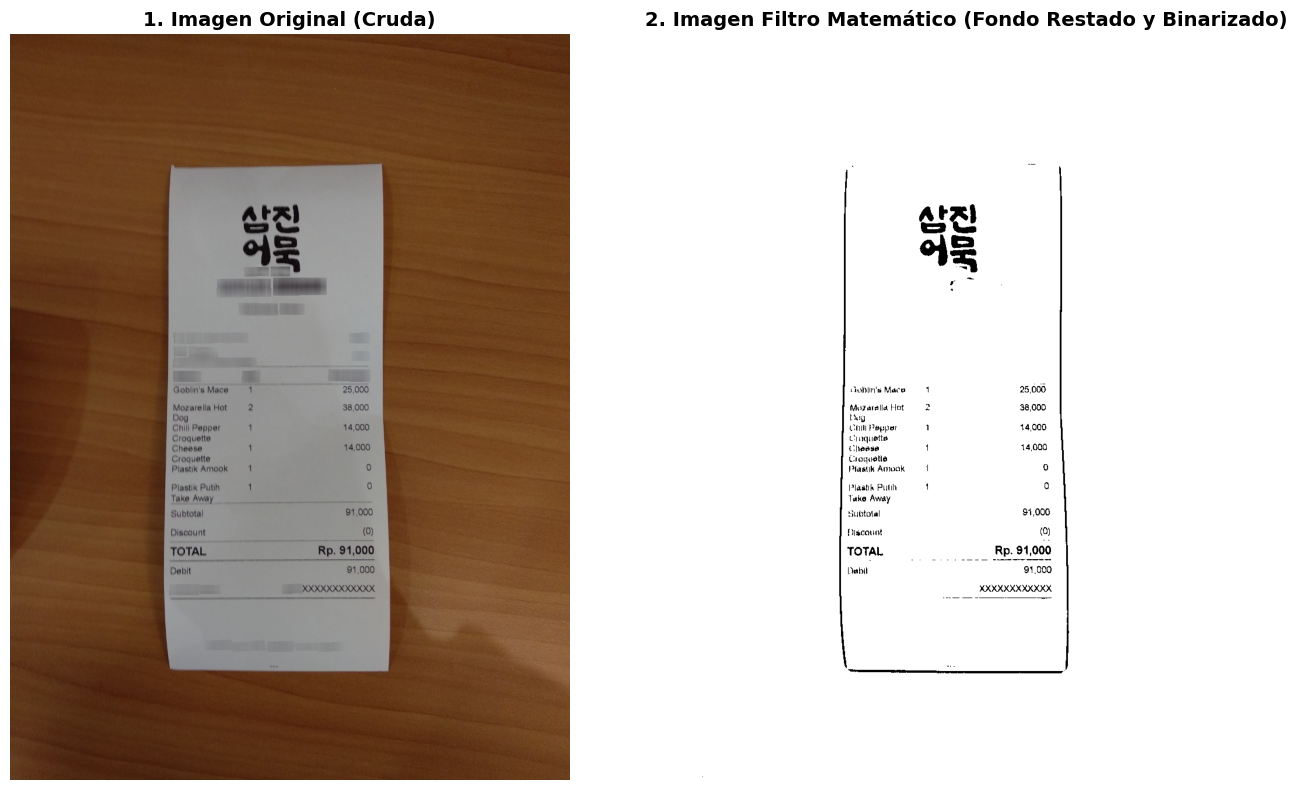

-------------- 3. RESULTADOS PREDICHOS (IA & BUSCADOR SEMÁNTICO) ---------------
  • HEADER: Aki
  • BODY: 95 1 iuhlln' Mace 25,005 Muzafallu Hot 38,OOD [J (MItlll /ekpar 14,000 ca,76btte {;hense 14,000 Cioquelle 1PlaIlIk A(nok...
  • FOOTER: 

  >> ✨ TOTAL DETECTADO TRAS PALABRA CLAVE ('Total' o 'TL'):  91,000





In [4]:
print("Descargando / Cargando partición de test del Dataset CORD...")
cord_ds = load_dataset("naver-clova-ix/cord-v2", split="test")

# Seleccionar 3 índices aleatorios
num_ejemplos = 3
indices_aleatorios = random.sample(range(len(cord_ds)), num_ejemplos)

for idx in indices_aleatorios:
    print("\n"+"="*80)
    print(f"  EVALUANDO FACTURA ÍNDICE: {idx}")
    print("="*80)
    
    pil_img = cord_ds[idx]['image']
    img_np = np.array(pil_img)
    if len(img_np.shape) == 3 and img_np.shape[2] == 3:
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    else:
        img_bgr = img_np.copy()
        
    # --- PROCESAMIENTO ---
    text_preds, raw_lists, prep_crops = ocr_engine.process_and_extract(img_bgr)
    
    full_prep_concat = np.vstack([prep_crops['Header'], prep_crops['Body'], prep_crops['Footer']])
    
    # --- BUSCADOR DEL TOTAL (Basado en Proximidad Derecha / Siguiente Caja) ---
    # Colapsamos todas las listas ordenadas de arriba a abajo
    full_raw_list = raw_lists['Header'] + raw_lists['Body'] + raw_lists['Footer']
    predicted_total = ocr_engine.find_total_value(full_raw_list)
    
    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    
    axes[0].set_title("1. Imagen Original (Cruda)", fontsize=14, fontweight='bold')
    axes[0].imshow(img_np)
    axes[0].axis('off')
    
    axes[1].set_title("2. Imagen Filtro Matemático (Fondo Restado y Binarizado)", fontsize=14, fontweight='bold')
    axes[1].imshow(full_prep_concat, cmap='gray')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # --- RESULTADOS ---
    print(" 3. RESULTADOS PREDICHOS (IA & BUSCADOR SEMÁNTICO) ".center(80, "-"))
    for k, v in text_preds.items():
        v_short = v.replace('\n', ' / ')
        if len(v_short) > 120: v_short = v_short[:120] + "..."
        print(f"  • {k.upper()}: {v_short}")
        
    print(f"\n  >> ✨ TOTAL DETECTADO TRAS PALABRA CLAVE ('Total' o 'TL'): ", f"{predicted_total}" if predicted_total else "No encontrado")
    print("\n\n")